# Chunked Uniform DTL Optimization

This notebook builds a global/uniform `gpurec` model from a folder containing `sp.nwk` and gene trees, then optimizes the three global DTL rates with ordinary PyTorch optimizers.

The model used here is `UniformChunkedReconModel`. It streams families in resident chunks, so it can run datasets that would OOM with a single fully resident `GeneReconModel`. The forward call computes the NLL and the analytical gradient internally; `loss.backward()` hands that cached gradient to PyTorch.

In [1]:
from pathlib import Path

import torch

from gpurec import UniformChunkedReconModel

torch.set_printoptions(precision=8, sci_mode=True)
device = "cuda"
assert torch.cuda.is_available(), "This optimized uniform path requires CUDA"

## Build The Model

The folder should contain a species tree named `sp.nwk` and gene trees matching `g_*.nwk`. Use `max_families` or `start` for quick subsets. The main OOM controls are:

- `family_chunk_size`: number of gene families kept resident at once; smaller uses less memory.
- `max_wave_size`: maximum number of clades in one scheduled wave; smaller reduces scratch memory.
- `dtype`: `torch.float32` is the default. `torch.float64` is stricter but slower and larger.
- `family_chunk_size="auto"` and `max_wave_size="auto"` use the current GPU memory policy.

In [2]:
#dataset_dir = Path("../tests/data/test_trees_1000")
dataset_dir = Path("/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_bench")
model = UniformChunkedReconModel.from_folder(
    dataset_dir,
    device=device,
    dtype=torch.float32,
    theta_init_rates=(0.05, 0.05, 0.05),
    max_families=1000,
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    family_chunk_size=100,
    max_wave_size=8192,
    fixed_iters_Pi=4,
    neumann_terms=3,
    use_pruning=True,
    pruning_threshold=1e-6,
    profile=True,  # records CUDA-event component timings in model.last_stats
)

model.batch_summary()

{'families': 1000,
 'species': 1325,
 'chunks': 10,
 'family_chunk_size': 100,
 'max_wave_size': 8192,
 'max_root_wave_size': None,
 'clade_budget': None,
 'fixed_iters_E': None,
 'fixed_iters_Pi': 4,
 'total_clades': 324940,
 'total_splits': 403425,
 'max_chunk_clades': 44984,
 'max_chunk_splits': 55955,
 'max_wave': 8192,
 'total_waves': 533,
 'dtype': 'float32',
 'device': 'cuda',
 'memory_policy': None}

## Single Objective And Gradient Evaluation

In [4]:
model.zero_grad(set_to_none=True)
loss = model()
loss.backward()

print("NLL bits:", float(loss.detach().cpu()))
print("rates D,L,T:", model.rates.detach().cpu().numpy())
print("theta grad:", model.theta.grad.detach().cpu().numpy())
model.last_stats

NLL bits: 685099.0625
rates D,L,T: [0.05 0.05 0.05]
theta grad: [ -2197.881 -19340.668 -26122.178]


{'loss': 685099.0625,
 'forward_ms': 107.91756731271744,
 'e_ms': 0.6790400147438049,
 'pi_forward_ms': 107.23852729797363,
 'backward_ms': 424.6212749481201,
 'pi_backward_ms': 413.9605712890625,
 'e_adjoint_ms': 10.660703659057617,
 'total_ms': 532.5388422608376,
 'peak_alloc_gib': 1.6584100723266602,
 'peak_reserved_gib': 2.5546875,
 'chunk_rows': [{'idx': 0,
   'family_start': 0,
   'family_stop': 100,
   'families': 100,
   'clades': 35640,
   'splits': 44275,
   'waves': 51,
   'max_wave': 8192,
   'split_rows': 44275,
   'max_wave_split_rows': 2826,
   'forward_ms': 10.538911819458008,
   'pi_backward_ms': 43.3908805847168},
  {'idx': 1,
   'family_start': 100,
   'family_stop': 200,
   'families': 100,
   'clades': 44984,
   'splits': 55955,
   'waves': 56,
   'max_wave': 8192,
   'split_rows': 55955,
   'max_wave_split_rows': 3521,
   'forward_ms': 12.709600448608398,
   'pi_backward_ms': 47.68876647949219},
  {'idx': 2,
   'family_start': 200,
   'family_stop': 300,
   'famil

In [ ]:
opt = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=12,
    max_eval=60,
    history_size=10,
    tolerance_grad=1e-5,
    tolerance_change=1e-9,
    line_search_fn="strong_wolfe",
)

evals = []

def closure():
    model.clamp_theta_(min_rate=1e-10)
    opt.zero_grad(set_to_none=True)
    loss = model()
    loss.backward()
    evals.append(float(loss.detach().cpu()))
    print(len(evals), evals[-1], model.rates.detach().cpu().numpy())
    return loss

opt.step(closure)
model.clamp_theta_(min_rate=1e-10)
print("final rates:", model.rates.detach().cpu().numpy())
print("last stats:", model.last_stats)

## Optimize With Adam

The lower bound is applied after each optimizer step to avoid rate underflow.

In [5]:
adam_model = model
opt = torch.optim.Adam(adam_model.parameters(), lr=0.05)

history = []
for step in range(10):
    opt.zero_grad(set_to_none=True)
    loss = adam_model()
    loss.backward()
    opt.step()
    adam_model.clamp_theta_(min_rate=1e-10)
    history.append(float(loss.detach().cpu()))
    print(step, history[-1], adam_model.rates.detach().cpu().numpy())

history

0 84356.46875 [0.05176326 0.05176326 0.05176326]
1 84065.0 [0.05357378 0.05358892 0.0535881 ]
2 83776.4375 [0.05541613 0.05547939 0.05547627]
3 83490.90625 [0.057266   0.05743715 0.05742946]
4 83208.4765625 [0.05908801 0.05946476 0.05944935]
5 82929.171875 [0.06083368 0.06156488 0.06153757]
6 82652.984375 [0.06244361 0.0637403  0.06369577]
7 82379.75 [0.06385478 0.06599383 0.06592551]
8 82109.265625 [0.06501289 0.06832842 0.06822829]
9 81841.328125 [0.065885   0.07074712 0.07060562]


[84356.46875,
 84065.0,
 83776.4375,
 83490.90625,
 83208.4765625,
 82929.171875,
 82652.984375,
 82379.75,
 82109.265625,
 81841.328125]

## Optimize With PyTorch LBFGS

For the 3 global rates, LBFGS usually needs fewer full objective/gradient evaluations than first-order optimizers. The closure pattern is standard PyTorch.

In [4]:
from pathlib import Path

import torch

from gpurec import UniformChunkedReconModel

dataset_dir = Path("../tests/data/test_trees_1000")
device = "cuda"

lbfgs_model = UniformChunkedReconModel.from_folder(
    dataset_dir,
    device=device,
    dtype=torch.float32,
    theta_init_rates=(2.5132962e-07, 1.7663820e-07, 3.2149110e-02),
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    family_chunk_size="auto",
    max_wave_size="auto",
    fixed_iters_Pi=6,
    profile=True,
)

opt = torch.optim.LBFGS(
    lbfgs_model.parameters(),
    lr=1.0,
    max_iter=12,
    max_eval=60,
    history_size=10,
    tolerance_grad=1e-5,
    tolerance_change=1e-9,
    line_search_fn="strong_wolfe",
)

evals = []

def closure():
    lbfgs_model.clamp_theta_(min_rate=1e-10)
    opt.zero_grad(set_to_none=True)
    loss = lbfgs_model()
    loss.backward()
    evals.append(float(loss.detach().cpu()))
    print(len(evals), evals[-1], lbfgs_model.rates.detach().cpu().numpy())
    return loss

opt.step(closure)
lbfgs_model.clamp_theta_(min_rate=1e-10)
print("final rates:", lbfgs_model.rates.detach().cpu().numpy())
print("last stats:", lbfgs_model.last_stats)

1 1757600.25 [2.5132962e-07 1.7663820e-07 3.2149110e-02]
2 1779305.875 [2.6175280e-07 1.6945329e-07 1.7451055e-02]
3 1757600.75 [2.5133062e-07 1.7663727e-07 3.2146890e-02]
4 1757601.125 [2.5132962e-07 1.7663820e-07 3.2148886e-02]
5 1757600.25 [2.5132962e-07 1.7663820e-07 3.2149110e-02]
final rates: [2.5132962e-07 1.7663820e-07 3.2149110e-02]
last stats: {'loss': 1757600.25, 'forward_ms': 2427.046604782343, 'e_ms': 0.4557119905948639, 'pi_forward_ms': 2426.590892791748, 'backward_ms': 3455.2696285247803, 'pi_backward_ms': 3449.565948486328, 'e_adjoint_ms': 5.703680038452148, 'total_ms': 5882.316233307123, 'peak_alloc_gib': 5.942367076873779, 'peak_reserved_gib': 14.630859375, 'chunk_rows': [{'idx': 0, 'family_start': 0, 'family_stop': 25, 'families': 25, 'clades': 161987, 'splits': 202415, 'waves': 56, 'max_wave': 8192, 'split_rows': 202415, 'max_wave_split_rows': 26897, 'forward_ms': 61.235008239746094, 'pi_backward_ms': 86.29759979248047}, {'idx': 1, 'family_start': 25, 'family_stop':

In [2]:
from pathlib import Path

import torch

from gpurec import UniformChunkedReconModel

dataset_dir = Path("../tests/data/test_trees_1000")
device = "cuda"

lbfgs_model = UniformChunkedReconModel.from_folder(
    dataset_dir,
    device=device,
    dtype=torch.float32,
    theta_init_rates=(2.5132962e-07, 1.7663820e-07, 3.2149110e-02),
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    family_chunk_size="auto",
    max_wave_size="auto",
    fixed_iters_Pi=6,
    profile=True,
)

# More exact / more expensive polish settings.
# Leave pruning enabled, but keep a positive threshold. Setting the threshold to
# 0.0 keeps the pruning machinery while making almost every adjoint active.
lbfgs_model._state.use_pruning = True
lbfgs_model._state.pruning_threshold = 1e-6

# Make the LBFGS closure deterministic: strong-Wolfe line search evaluates the
# closure multiple times at trial parameters, so warm-starting E from the
# previous trial can make the objective stateful.
lbfgs_model._state.warm_start_E = False
lbfgs_model.clear_warm_start()

# Stricter E solve. max_iters_E is an iteration cap, so 5 was less strict, not
# more strict; it could leave E under-converged.
lbfgs_model._state.tol_E = 1e-10
lbfgs_model._state.max_iters_E = 2000

# More accurate backward solve.
lbfgs_model._state.neumann_terms = 6
lbfgs_model._state.cg_tol = 1e-10
lbfgs_model._state.cg_maxiter = 50
lbfgs_model._state.gmres_restart = 20

# Keep the same forward fixed-point budget used by the optimized kernels.
lbfgs_model._state.fixed_iters_Pi = 6

# Clamp outside the LBFGS closure. Mutating parameters inside the closure can
# confuse the line search because the closure is called at multiple trial points.
min_rate = 1e-10
lbfgs_model.clamp_theta_(min_rate=min_rate)
theta_before = lbfgs_model.theta.detach().clone()
rates_before = lbfgs_model.rates.detach().clone()

opt_polish = torch.optim.LBFGS(
    lbfgs_model.parameters(),
    lr=1.0,              # LBFGS usually wants lr=1; 0.01 makes the first step tiny.
    max_iter=4,
    max_eval=12,
    history_size=10,
    tolerance_grad=1e-6,
    tolerance_change=1e-10,
    line_search_fn="strong_wolfe",
)

polish_evals = []

def polish_closure():
    opt_polish.zero_grad(set_to_none=True)

    print("starting polish eval", len(polish_evals) + 1)
    loss = lbfgs_model()
    print("loss computed", float(loss.detach().cpu()))

    loss.backward()
    polish_evals.append(float(loss.detach().cpu()))
    print(
        "polish", len(polish_evals),
        polish_evals[-1],
        lbfgs_model.rates.detach().cpu().numpy(),
        "theta", lbfgs_model.theta.detach().cpu().numpy(),
        "grad", lbfgs_model.theta.grad.detach().cpu().numpy(),
    )
    return loss

opt_polish.step(polish_closure)
lbfgs_model.clamp_theta_(min_rate=min_rate)

theta_after = lbfgs_model.theta.detach().clone()
rates_after = lbfgs_model.rates.detach().clone()
print("polished rates:", rates_after.cpu().numpy())
print("delta theta:", (theta_after - theta_before).cpu().numpy())
print("relative rate change:", ((rates_after / rates_before) - 1).cpu().numpy())
print("polished stats:", {k: v for k, v in lbfgs_model.last_stats.items() if k != "chunk_rows"})


starting polish eval 1
loss computed 1757600.25
polish 1 1757600.25 [2.5132962e-07 1.7663820e-07 3.2149110e-02] theta [-21.923916  -22.4327     -4.9590774] grad [-0.43097338  0.44042403  6.479956  ]
starting polish eval 2
loss computed 1779305.875
polish 2 1779305.875 [2.6175280e-07 1.6945329e-07 1.7451055e-02] theta [-21.865292 -22.492609  -5.840542] grad [-5.9159583e-01  3.7493813e-01 -4.4922059e+04]
starting polish eval 3
loss computed 1757600.75
polish 3 1757600.75 [2.5133062e-07 1.7663727e-07 3.2146890e-02] theta [-21.92391  -22.432707  -4.959177] grad [-0.43099126  0.44041872 -0.2075442 ]
starting polish eval 4
loss computed 1757601.125
polish 4 1757601.125 [2.5132962e-07 1.7663820e-07 3.2148886e-02] theta [-21.923916  -22.4327     -4.9590874] grad [-0.43097845  0.44042388  5.769018  ]
starting polish eval 5
loss computed 1757600.25
polish 5 1757600.25 [2.5132962e-07 1.7663820e-07 3.2149110e-02] theta [-21.923916  -22.4327     -4.9590774] grad [-0.43097338  0.44042403  6.479956  

In [14]:
def set_rates(model, rates):
    rates = torch.tensor(rates, device=model.theta.device, dtype=model.theta.dtype)
    if torch.any(rates <= 0):
        raise ValueError("rates must be positive")
    with torch.no_grad():
        model.theta.copy_(torch.log2(rates))
        model.clear_warm_start()

#set_rates(lbfgs_model, (2.5132962e-07, 1.7663820e-07, 3.2149110e-02))
set_rates(lbfgs_model, (1e-10, 1e-10, 3.2149110e-02))
lbfgs_model.nll()

tensor(1757605.6250, device='cuda:0')

In [9]:
lbfgs_model.nll()

tensor(1757600.2500, device='cuda:0')

In [7]:
for i in range(10):
    opt.step(closure)
    lbfgs_model.clamp_theta_(min_rate=1e-10)
    print("final rates:", lbfgs_model.rates.detach().cpu().numpy())

14 1757719.5 [1.7867264e-05 1.6658603e-05 3.2147855e-02]
15 1757658.375 [9.521095e-06 8.521068e-06 3.213740e-02]
16 1757628.0 [5.085293e-06 4.364657e-06 3.218443e-02]
17 1757621.625 [2.5451320e-06 2.0876894e-06 3.1769495e-02]
18 1757609.125 [1.9061663e-06 1.5335133e-06 3.2052707e-02]
19 1757604.5 [1.1833278e-06 9.2234194e-07 3.2174610e-02]
20 1757602.75 [7.4202438e-07 5.6078886e-07 3.2183845e-02]
21 1757601.625 [4.3364045e-07 3.1605836e-07 3.2082956e-02]
22 1757600.875 [3.5317132e-07 2.5393044e-07 3.2129914e-02]
23 1757600.875 [2.7781479e-07 1.9657384e-07 3.2149926e-02]
final rates: [2.7781479e-07 1.9657384e-07 3.2149926e-02]
24 1757600.875 [2.7781479e-07 1.9657384e-07 3.2149926e-02]
25 1757600.25 [2.5133062e-07 1.7663891e-07 3.2149110e-02]
26 1757600.5 [2.4281798e-07 1.6997429e-07 3.2147188e-02]
27 1757600.25 [2.5131001e-07 1.7662279e-07 3.2149110e-02]
28 1757600.25 [2.513263e-07 1.766354e-07 3.214911e-02]
29 1757600.25 [2.5132962e-07 1.7663820e-07 3.2149110e-02]
30 1757600.25 [2.5133

KeyboardInterrupt: 

In [1]:
from pathlib import Path

import torch

from gpurec import UniformChunkedReconModel

model64 = UniformChunkedReconModel.from_folder(
    "../tests/data/test_trees_1000",
    max_families=1000,
    device="cuda",
    dtype=torch.float64,
    theta_init_rates=(2.5132962e-07, 1.7663820e-07, 3.2149110e-02),
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    family_chunk_size=10,
    max_wave_size=4096,
    fixed_iters_Pi=6,
    profile=True,
)

with torch.no_grad():
    loss = model64.nll()

print(float(loss.cpu()))
print({k: v for k, v in model64.last_stats.items() if k != "chunk_rows"})

KeyboardInterrupt: 

In [ ]:
from pathlib import Path

import torch

from gpurec import UniformChunkedReconModel

model64 = UniformChunkedReconModel.from_folder(
    "../tests/data/test_trees_1000",
    device="cuda",
    dtype=torch.float64,
    theta_init_rates=(2.5132962e-07, 1.7663820e-07, 3.2149110e-02),  # from fp32 result
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    family_chunk_size=10,      # fp64 uses 2x memory; lower this if OOM
    max_wave_size=4096,
    fixed_iters_Pi=6,
    profile=True,
)
print("model constructed")
print(model64.batch_summary())

# Use nll() under no_grad for an evaluation-only fp64 check. Calling model64()
# computes the differentiable objective and keeps the autograd work alive.
with torch.no_grad():
    initial_nll = model64.nll()
print("initial fp64 NLL:", float(initial_nll.detach().cpu()))
print("initial fp64 stats:", {k: v for k, v in model64.last_stats.items() if k != "chunk_rows"})

# Optional fp64 polish. This is intentionally small because one fp64 closure on
# all 1000 trees is expensive; increase max_iter/max_eval only after checking
# that each closure time is acceptable.
model64._state.use_pruning = True
model64._state.pruning_threshold = 1e-6
model64._state.warm_start_E = False
model64.clear_warm_start()
model64._state.tol_E = 1e-10
model64._state.max_iters_E = 2000
model64._state.neumann_terms = 6
model64._state.cg_tol = 1e-10
model64._state.cg_maxiter = 50
model64._state.gmres_restart = 20

opt64 = torch.optim.LBFGS(
    model64.parameters(),
    lr=0.01,
    max_iter=1,
    max_eval=2,
    history_size=10,
    tolerance_grad=1e-6,
    tolerance_change=1e-10,
    line_search_fn="strong_wolfe",
)

fp64_evals = []

def fp64_closure():
    model64.clamp_theta_(min_rate=1e-10)
    opt64.zero_grad(set_to_none=True)
    print("starting fp64 eval", len(fp64_evals) + 1)
    loss = model64()
    print("fp64 loss computed", float(loss.detach().cpu()))
    loss.backward()
    fp64_evals.append(float(loss.detach().cpu()))
    print("fp64", len(fp64_evals), fp64_evals[-1], model64.rates.detach().cpu().numpy())
    return loss

opt64.step(fp64_closure)
model64.clamp_theta_(min_rate=1e-10)

print("fp64 rates:", model64.rates.detach().cpu().numpy())
with torch.no_grad():
    final_nll = model64.nll()
print("fp64 NLL:", float(final_nll.detach().cpu()))
print("last stats:", {k: v for k, v in model64.last_stats.items() if k != "chunk_rows"})


## Manual Memory Settings

If the auto policy is too aggressive for another GPU or for a concurrent workload, make the resident chunks smaller. This lowers peak memory at the cost of more chunk launches.

In [21]:
small_memory_model = UniformChunkedReconModel.from_folder(
    dataset_dir,
    device=device,
    dtype=torch.float32,
    theta_init_rates=(0.05, 0.05, 0.05),
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    family_chunk_size=10,
    max_wave_size=4096,
    fixed_iters_Pi=6,
    profile=True,
)

small_memory_model.batch_summary()

{'families': 1055,
 'species': 1325,
 'chunks': 106,
 'family_chunk_size': 10,
 'max_wave_size': 4096,
 'max_root_wave_size': None,
 'clade_budget': None,
 'total_clades': 341089,
 'total_splits': 423460,
 'max_chunk_clades': 8562,
 'max_chunk_splits': 10675,
 'max_wave': 2153,
 'total_waves': 4233,
 'dtype': 'float32',
 'device': 'cuda',
 'memory_policy': None}

## Per-Family NLL For Inspection

`nll_per_family()` uses the forward-only root-row path and does not compute gradients.

In [ ]:
with torch.no_grad():
    per_family = lbfgs_model.nll_per_family()

print(per_family.shape, per_family[:10].detach().cpu())
print("sum:", float(per_family.sum().detach().cpu()))

# HOGENOM

In [ ]:

from pathlib import Path
import torch
from gpurec import GeneReconModel

dataset_dir = Path("/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_bench")


def gene_family_id(path: Path) -> int:
    return int(path.stem.split("_")[1])


gene_trees = sorted(dataset_dir.glob("g_*.nwk"), key=gene_family_id)
family_ids = [gene_family_id(path) for path in gene_trees]
assert family_ids == list(range(len(family_ids))), family_ids[:10]

model = GeneReconModel.from_trees(
    species_tree=str(dataset_dir / "sp.nwk"),
    gene_trees=[str(p) for p in gene_trees],
    mode="genewise",
    pibar_mode="uniform",
    device="cuda",
    dtype=torch.float32,
    theta_init_rates=(0.05, 0.05, 0.05),
    preprocess_cache_dir="/tmp/gpurec_notebook_cache",
    fixed_iters_Pi=4,
    fixed_iters_E=4,
    neumann_terms=4,
    use_pruning=False,
    pruning_threshold=1e-6,
    max_wave_size=8192,
)

print(model.theta.shape)   # [G, 3]
print(model.rates.shape)   # [G, 3]

loss = model()             # summed NLL over families
loss.backward()

print(model.theta.grad.shape)  # [G, 3]

with torch.no_grad():
    nll_per_family = model.nll_per_family()
print(nll_per_family.shape)  # [G]

opt = torch.optim.Adagrad(model.parameters(), lr=1)
evals = []

for step in range(100):
    model.clamp_theta_(min_rate=1e-10, max_rate=2.0)
    opt.zero_grad(set_to_none=True)
    loss = model.nll_per_family()  # scalar loss for autograd
    loss_sum = loss.sum()
    loss_sum.backward()
    # show model likelihoods
    print("step", step, "loss", loss)
    opt.step()



import csv

rates_np = model.rates.detach().cpu().numpy()
out_path = dataset_dir / "gpurec" / "model_rates.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
nll_per_family = model.nll_per_family().detach().cpu()

if rates_np.ndim != 2:
    raise ValueError("Expected genewise rates with shape [families, 3]")
if len(rates_np) != len(gene_trees):
    raise ValueError(f"rates rows ({len(rates_np)}) != gene trees ({len(gene_trees)})")

with out_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["family_id", "family", "gene_file", "D", "L", "T", "nll"])
    for family_id, gene_path, row, nll in zip(
        family_ids,
        gene_trees,
        rates_np.tolist(),
        nll_per_family.tolist(),
    ):
        writer.writerow([family_id, f"family_{family_id:04d}", gene_path.name, *row, nll])

print(f"Saved rates to: {out_path}")


from pathlib import Path
import pandas as pd

root = Path("/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_bench")


def family_id_from_gene_file(name: str) -> int:
    return int(Path(name).stem.split("_")[1])


def add_gpurec_family_metadata(df: pd.DataFrame, root: Path) -> pd.DataFrame:
    df = df.copy()
    if "family_id" not in df.columns:
        # Legacy exports had no identifiers and were written in lexicographic g_*.nwk order.
        legacy_gene_trees = sorted(root.glob("g_*.nwk"))
        if len(df) != len(legacy_gene_trees):
            raise ValueError(
                "gpurec/model_rates.csv has no family_id column, and its row count "
                f"({len(df)}) does not match the legacy gene tree count ({len(legacy_gene_trees)}). "
                "Regenerate it with the export cell above."
            )
        family_ids = [family_id_from_gene_file(path.name) for path in legacy_gene_trees]
        df.insert(0, "family_id", family_ids)
        df.insert(1, "family", [f"family_{family_id:04d}" for family_id in family_ids])
        df.insert(2, "gene_file", [path.name for path in legacy_gene_trees])
        print("Using legacy gpurec CSV mapping: rows are interpreted in lexicographic g_*.nwk order.")
    else:
        df["family_id"] = df["family_id"].astype(int)
        if "family" not in df.columns:
            df.insert(1, "family", [f"family_{family_id:04d}" for family_id in df["family_id"]])
        if "gene_file" not in df.columns:
            df.insert(2, "gene_file", [f"g_{family_id}.nwk" for family_id in df["family_id"]])
    return df


gpurec = add_gpurec_family_metadata(pd.read_csv(root / "gpurec" / "model_rates.csv"), root)
alerax = pd.read_csv(root / "output_global" / "model_rates.csv")
if "family_id" not in alerax.columns:
    alerax = alerax.copy()
    alerax.insert(0, "family_id", alerax.index.astype(int))

cols = ["D", "L", "T"]

rates_comparison = gpurec[["family_id", "family", "gene_file", *cols]].merge(
    alerax[["family_id", *cols]],
    on="family_id",
    how="left",
    suffixes=("_gpurec", "_alerax"),
).sort_values("family_id", ignore_index=True)

missing_alerax = rates_comparison.loc[
    rates_comparison[[f"{col}_alerax" for col in cols]].isna().any(axis=1),
    "family_id",
].tolist()

for col in cols:
    rates_comparison[f"diff_{col}"] = rates_comparison[f"{col}_gpurec"] - rates_comparison[f"{col}_alerax"]
    rates_comparison[f"abs_diff_{col}"] = rates_comparison[f"diff_{col}"].abs()
    rates_comparison[f"rel_diff_{col}"] = (
        rates_comparison[f"abs_diff_{col}"]
        / rates_comparison[f"{col}_alerax"].abs().clip(lower=1e-12)
    )

valid_rates = rates_comparison.dropna(subset=[f"{col}_alerax" for col in cols])

print("gpurec shape:", gpurec.shape)
print("alerax shape:", alerax.shape)
print("common rows:", len(valid_rates))
print("missing ALERax families:", missing_alerax)
print("max abs diff:")
print(valid_rates[[f"abs_diff_{col}" for col in cols]].max())
print("max rel diff:")
print(valid_rates[[f"rel_diff_{col}" for col in cols]].max())

print(valid_rates.head())
print(
    valid_rates
    .set_index("family_id")[[f"abs_diff_{col}" for col in cols]]
    .stack()
    .sort_values(ascending=False)
    .head(20)
)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for ax, col in zip(axes, cols):
    plot_df = valid_rates.dropna(subset=[f"{col}_alerax", f"{col}_gpurec"])
    x = plot_df[f"{col}_alerax"]
    y = plot_df[f"{col}_gpurec"]
    r = x.corr(y)

    ax.scatter(x, y, s=12, alpha=0.6)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "--", color="red", linewidth=1)

    ax.set_title(f"{col} (r={r:.3f})")
    ax.set_xlabel(f"ALERax {col}")
    ax.set_ylabel(f"gpurec {col}")

plt.show()


torch.Size([1055, 3])
torch.Size([1055, 3])
torch.Size([1055, 3])
torch.Size([1055])
step 0 loss tensor([365.5177, 250.5856, 203.6795,  ..., 156.6430, 206.7508,  93.1469],
       device='cuda:0', grad_fn=<_GeneReconFunctionBackward>)
step 1 loss tensor([341.8731, 234.7757, 188.7502,  ..., 148.6768, 192.3493,  86.1655],
       device='cuda:0', grad_fn=<_GeneReconFunctionBackward>)
step 2 loss tensor([328.3303, 225.5150, 180.8740,  ..., 144.3851, 183.5043,  81.4337],
       device='cuda:0', grad_fn=<_GeneReconFunctionBackward>)
step 3 loss tensor([319.7968, 220.3223, 175.9688,  ..., 138.9247, 177.5490,  78.3347],
       device='cuda:0', grad_fn=<_GeneReconFunctionBackward>)
step 4 loss tensor([314.6926, 217.2081, 172.8246,  ..., 136.8719, 173.5505,  76.6117],
       device='cuda:0', grad_fn=<_GeneReconFunctionBackward>)
step 5 loss tensor([311.6320, 215.3239, 170.8763,  ..., 136.3511, 170.9530,  75.7324],
       device='cuda:0', grad_fn=<_GeneReconFunctionBackward>)
step 6 loss tensor([3

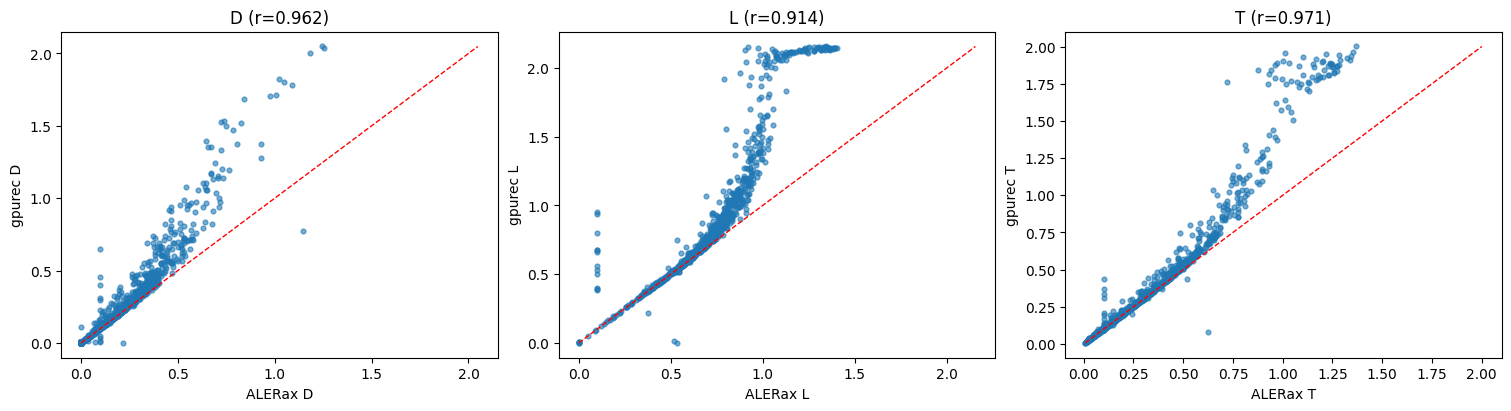

In [30]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for ax, col in zip(axes, cols):
    plot_df = valid_rates.dropna(subset=[f"{col}_alerax", f"{col}_gpurec"])
    x = plot_df[f"{col}_alerax"]
    y = plot_df[f"{col}_gpurec"]
    r = x.corr(y)

    ax.scatter(x, y, s=12, alpha=0.6)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "--", color="red", linewidth=1)

    ax.set_title(f"{col} (r={r:.3f})")
    ax.set_xlabel(f"ALERax {col}")
    ax.set_ylabel(f"gpurec {col}")

plt.show()


In [ ]:

from pathlib import Path
import pandas as pd

root = Path("/home/enzo/Documents/git/gpurec/gpurec/tests/data/hogenom_bench")


def family_id_from_gene_file(name: str) -> int:
    return int(Path(name).stem.split("_")[1])


def add_gpurec_family_metadata(df: pd.DataFrame, root: Path) -> pd.DataFrame:
    df = df.copy()
    if "family_id" not in df.columns:
        # Legacy exports had no identifiers and were written in lexicographic g_*.nwk order.
        legacy_gene_trees = sorted(root.glob("g_*.nwk"))
        if len(df) != len(legacy_gene_trees):
            raise ValueError(
                "gpurec/model_rates.csv has no family_id column, and its row count "
                f"({len(df)}) does not match the legacy gene tree count ({len(legacy_gene_trees)}). "
                "Regenerate it with the export cell above."
            )
        family_ids = [family_id_from_gene_file(path.name) for path in legacy_gene_trees]
        df.insert(0, "family_id", family_ids)
        df.insert(1, "family", [f"family_{family_id:04d}" for family_id in family_ids])
        df.insert(2, "gene_file", [path.name for path in legacy_gene_trees])
        print("Using legacy gpurec CSV mapping: rows are interpreted in lexicographic g_*.nwk order.")
    else:
        df["family_id"] = df["family_id"].astype(int)
        if "family" not in df.columns:
            df.insert(1, "family", [f"family_{family_id:04d}" for family_id in df["family_id"]])
        if "gene_file" not in df.columns:
            df.insert(2, "gene_file", [f"g_{family_id}.nwk" for family_id in df["family_id"]])
    return df


gpurec = add_gpurec_family_metadata(pd.read_csv(root / "gpurec" / "model_rates.csv"), root)
alerax = pd.read_csv(root / "output_global" / "per_fam_likelihoods_sorted.csv")

likelihood_comparison = gpurec[["family_id", "family", "gene_file", "nll"]].merge(
    alerax[["family_id", "alerax_nll_nats", "alerax_nll_bits"]],
    on="family_id",
    how="left",
).sort_values("family_id", ignore_index=True)

likelihood_comparison = likelihood_comparison.rename(columns={"nll": "gpurec_nll_bits"})
likelihood_comparison["diff_gpurec_minus_alerax_bits"] = (
    likelihood_comparison["gpurec_nll_bits"] - likelihood_comparison["alerax_nll_bits"]
)
likelihood_comparison["abs_diff_bits"] = likelihood_comparison["diff_gpurec_minus_alerax_bits"].abs()

valid_likelihoods = likelihood_comparison.dropna(subset=["alerax_nll_bits"])

print("rows:", len(likelihood_comparison))
print("common rows:", len(valid_likelihoods))
print("missing ALERax:", likelihood_comparison.loc[likelihood_comparison["alerax_nll_bits"].isna(), "family_id"].tolist())

print("Bits abs diff:")
print(valid_likelihoods["abs_diff_bits"].describe())

print("Worst GPUREC better than ALERax:")
print(valid_likelihoods.sort_values("diff_gpurec_minus_alerax_bits").head(20))

print("Worst GPUREC worse than ALERax:")
print(valid_likelihoods.sort_values("diff_gpurec_minus_alerax_bits", ascending=False).head(20))


rows: 1055
common rows: 1042
missing ALERax: [38, 179, 283, 296, 303, 477, 570, 624, 681, 739, 781, 958, 1046]
Bits abs diff:
count    1042.000000
mean        1.990390
std         9.866168
min         0.000019
25%         0.086350
50%         0.368997
75%         1.081583
max       121.638277
Name: abs_diff_bits, dtype: float64
Worst GPUREC better than ALERax:
     family_id       family  gene_file  gpurec_nll_bits  alerax_nll_nats  \
631        631  family_0631  g_631.nwk       929.095276          728.313   
956        956  family_0956  g_956.nwk       946.779724          729.292   
410        410  family_0410  g_410.nwk       957.375427          735.977   
561        561  family_0561  g_561.nwk       952.580750          728.853   
384        384  family_0384  g_384.nwk       960.506409          733.826   
763        763  family_0763  g_763.nwk       986.434998          744.440   
507        507  family_0507  g_507.nwk       986.701294          744.440   
701        701  family_0701  

In [ ]:
valid_likelihoods


,family_id,family,gene_file,gpurec_nll_bits,alerax_nll_nats,alerax_nll_bits,diff_gpurec_minus_alerax_bits,abs_diff_bits
0,0,family_0000,g_0.nwk,306.536743,213.7340,308.352982,-1.816239,1.816239
1,1,family_0001,g_1.nwk,213.062225,147.9050,213.381810,-0.319585,0.319585
2,2,family_0002,g_2.nwk,168.096939,116.6880,168.345199,-0.248260,0.248260
3,3,family_0003,g_3.nwk,422.052490,293.0890,422.838047,-0.785557,0.785557
4,4,family_0004,g_4.nwk,443.800232,310.6840,448.222266,-4.422034,4.422034
...,...,...,...,...,...,...,...,...
1050,1050,family_1050,g_1050.nwk,137.885315,95.7193,138.093759,-0.208444,0.208444
1051,1051,family_1051,g_1051.nwk,557.639526,386.6320,557.792069,-0.152543,0.152543
1052,1052,family_1052,g_1052.nwk,136.190918,94.4949,136.327324,-0.136406,0.136406
1053,1053,family_1053,g_1053.nwk,163.679764,115.1130,166.072954,-2.393190,2.393190


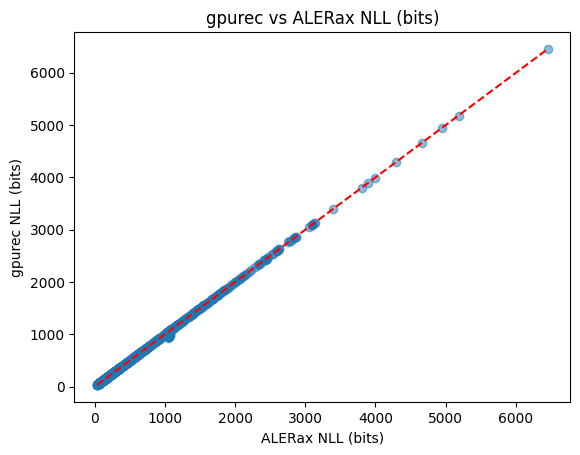

In [24]:
# plot alerax vs gpurec likelihoods
plt.scatter(valid_likelihoods["alerax_nll_bits"], valid_likelihoods["gpurec_nll_bits"], alpha=0.5)
plt.plot(
    [valid_likelihoods[["alerax_nll_bits", "gpurec_nll_bits"]].min().min(), valid_likelihoods[["alerax_nll_bits", "gpurec_nll_bits"]].max().max()], 
    [valid_likelihoods[["alerax_nll_bits", "gpurec_nll_bits"]].min().min(), valid_likelihoods[["alerax_nll_bits", "gpurec_nll_bits"]].max().max()], 
    color='red', linestyle='--'
)
plt.xlabel("ALERax NLL (bits)")
plt.ylabel("gpurec NLL (bits)")
plt.title("gpurec vs ALERax NLL (bits)")
plt.show()